# From Period Finding to Factoring: Shor's Algorithm

### Overview

**Goal:** Factor an integer $N$ using a quantum computer.

**Key idea:** Reduce factoring to **period finding** → solve period finding efficiently with Quantum Fourier Transform (QFT).

**Why factoring matters:** Breaking RSA cryptography.

---

### Period (Order) of a Number modulo $N$

Pick a random $a < N$ that is **coprime** to $N$ (i.e., $\gcd(a,N)=1$).  
Define the function  

$$
f(x) = a^x \bmod N .
$$

- This function is **periodic**.
- The smallest positive $r$ such that $a^r \equiv 1 \pmod N$ is called the **order** of $a$ modulo $N$.
- Then $f(x+r)=a^{x+r}\bmod N = a^x \cdot a^r \bmod N = f(x)$.

---

### Example – Order of 7 modulo 15

$N=15,\; a=7$ (coprime because $\gcd(7,15)=1$)

$$
\begin{aligned}
7^0 \bmod 15 &= 1 \\
7^1 \bmod 15 &= 7 \\
7^2 \bmod 15 &= 49 \bmod 15 = 4 \\
7^3 \bmod 15 &= 4\cdot7 = 28 \bmod 15 = 13 \\
7^4 \bmod 15 &= 13\cdot7 = 91 \bmod 15 = 1
\end{aligned}
$$

The sequence repeats every 4 steps:  
$1,7,4,13,1,7,4,13,\dots$

**Order** $r = 4$.

---

### From Order to Factors

If $r$ is **even** and $a^{r/2} \not\equiv -1 \pmod N$, then  

$$
\gcd(a^{r/2} \pm 1,\; N)
$$

gives a **non‑trivial factor** of $N$.

**Example (N=15, a=7):**  
$r=4$ (even), $a^{r/2}=7^2=49 \equiv 4 \pmod{15}$.  
$4 \not\equiv -1 \equiv 14 \pmod{15}$.

$$
\gcd(4+1,15)=\gcd(5,15)=5,\qquad
\gcd(4-1,15)=\gcd(3,15)=3.
$$

Factors of 15 are 3 and 5.

---

### Quantum Period Finding – Registers

We need two quantum registers:

- **Input register** (holds exponent $x$): size $m$ qubits, dimension $Q=2^m$.  
  Requirement: $Q > N^2$ (enough resolution for QFT).  
  Typically $m \approx 2\lceil \log_2 N\rceil$.

- **Work register** (holds $f(x)=a^x \bmod N$): size $n = \lceil \log_2 N\rceil$ qubits.

**Example for $N=15$:**  
$n=4$ (since $2^4=16 > 15$). Choose $m=8$, so $Q=256 > 15^2=225$.

Initial state: $|\psi_0\rangle = |0\rangle^{\otimes m} |0\rangle^{\otimes n}$.

---

### Step 1 – Uniform Superposition

Apply Hadamard gates to every qubit of the input register:

$$
|\psi_1\rangle = \frac{1}{\sqrt{Q}} \sum_{x=0}^{Q-1} |x\rangle \otimes |0\rangle .
$$

**Example (Q=256):**

$$
|\psi_1\rangle = \frac{1}{16} \sum_{x=0}^{255} |x\rangle |0\rangle .
$$

---

### Step 2 – Modular Exponentiation

Apply a unitary $U_f$ that computes $f(x)=a^x \bmod N$ into the work register:

$$
U_f |x\rangle |0\rangle = |x\rangle |a^x \bmod N\rangle .
$$

Result:

$$
|\psi_2\rangle = \frac{1}{\sqrt{Q}} \sum_{x=0}^{Q-1} |x\rangle |a^x \bmod N\rangle .
$$

**Example (N=15, a=7):**  
$|\psi_2\rangle = \frac{1}{16}\bigl(|0\rangle|1\rangle + |1\rangle|7\rangle + |2\rangle|4\rangle + |3\rangle|13\rangle + |4\rangle|1\rangle + |5\rangle|7\rangle + \dots \bigr)$.

---

###  Step 3 – Measure the Work Register

We measure the work register and obtain some value $y = a^{x_0} \bmod N$.

The input register collapses to a superposition of all $x$ with the same $y$:

$$
|\psi_3\rangle = \frac{1}{\sqrt{M}} \sum_{j=0}^{M-1} |x_0 + j\cdot r\rangle ,
$$

where $M \approx Q/r$ is the number of such $x$ values.

**Example:** Suppose we measure $y = 13$.  
$13$ appears when $x \equiv 3 \pmod{4}$ (because $7^3=13$).  
Here $x_0 = 3$, $r=4$, $M = 256/4 = 64$:

$$
|\psi_3\rangle = \frac{1}{\sqrt{64}} \sum_{j=0}^{63} |3 + 4j\rangle .
$$

---

###  Step 4 – Apply Quantum Fourier Transform (QFT)

Apply the QFT to the **input register**.  
The QFT transforms a periodic state with spacing $r$ into a state with amplitude peaks at multiples of $Q/r$.

**Why?** The QFT of a comb of period $r$ is a comb of period $Q/r$ in the frequency domain.

**Example:** For $r=4,\; Q=256$, the peaks appear at  

$$
c = 0,\; \frac{Q}{r}=64,\; 2\cdot\frac{Q}{r}=128,\; 3\cdot\frac{Q}{r}=192.
$$

---

### Step 5 – Measure the Input Register

We measure the input register and obtain an integer $c$.

Because of the QFT, $c$ will be close to an integer multiple of $Q/r$:

$$
c \approx m \cdot \frac{Q}{r} \quad\text{for some integer } m.
$$

**Example:** A measurement might give $c = 128$ (which is exactly $2 \cdot 64$).

---

### Step 6 – Post‑processing with Continued Fractions

We have the rational number $c/Q$.  
We want to recover the unknown period $r$ from it.

$$
\frac{c}{Q} \approx \frac{m}{r}
$$

We use the **continued fraction expansion** of $c/Q$ to find a good approximation $m/r$ with small denominator $r < N$.

---

### What is a Continued Fraction?

A continued fraction represents a number as

$$
x = a_0 + \cfrac{1}{a_1 + \cfrac{1}{a_2 + \cfrac{1}{a_3 + \ddots}}}
$$

Shorthand: $x = [a_0; a_1, a_2, a_3, \dots]$.

---

**Convergents** are the fractions obtained by truncating the expansion at some depth.  
They give the best rational approximations to $x$.

**Example:** $\frac{128}{256} = \frac{1}{2} = [0;2]$.  
Convergents: $0/1$ and $1/2$. The denominator 2 is a candidate for $r$.

**Example:** $\frac{64}{256} = \frac{1}{4} = [0;4]$.  
Convergent $1/4$ gives denominator 4 → correct $r$.

---

### Continued Fraction Algorithm (to extract $r$)

Given $c/Q$ (a rational number between 0 and 1):

1. Compute its continued fraction expansion until the denominator exceeds $N$.
2. For each convergent $p/q$ with $q < N$, check if $a^q \equiv 1 \pmod N$.
3. If yes, $r = q$ (or a divisor thereof).  
   If not, continue to the next convergent.

**Example:** $c=128,\; Q=256,\; c/Q=0.5$  
Expansion: $0.5 = [0;2]$. Convergents: $1/2$.  
Check $7^2 \bmod 15 = 4 \neq 1$ → not the order.

We might need to try another measurement (e.g., $c=64$ gives $1/4$ → $r=4$ correct).

---

### Why Does the QFT Give Peaks at $mQ/r$?

The state after Step 3 is an equal superposition of $|x_0 + j r\rangle$.

Its QFT amplitude at frequency $k$ is:

$$
\tilde{\psi}(k) = \frac{1}{\sqrt{Q}} \sum_{j=0}^{M-1} e^{2\pi i k (x_0 + j r)/Q}.
$$

This sum is large only when $k r / Q$ is close to an integer, i.e., $k \approx m Q / r$.

Thus the probability peaks at $k = 0, \lfloor Q/r\rfloor, \lfloor 2Q/r\rfloor, \dots$.

---

### Practical Considerations

- A single measurement might give a $c$ that is not exactly $mQ/r$ (due to noise or because $Q$ is not a multiple of $r$).  
  The continued fraction algorithm still works if the approximation is good enough.

- The denominator from a convergent might be a **factor** of $r$ (e.g., $r/2$).  
  We then take the least common multiple of several successful candidates.

- If $r$ is odd or $a^{r/2} \equiv -1$, pick a different $a$ and repeat.

---

### Simulation Example (N=15, a=7)


- $Q=256$, $r=4$.
- After measuring work register = 13, input state is $|3\rangle+|7\rangle+|11\rangle+\dots$.
- Apply classical FFT (equivalent to QFT) to this periodic vector.
- The FFT will show peaks at indices 64, 128, 192.
- Measuring gives e.g. $c=64$ → $c/Q=1/4$ → continued fraction gives denominator 4 → $r=4$.
- Compute $a^{r/2} \pm 1$ → $\gcd(4\pm1,15)=3,5$.

---


Target: N = 15, a = 7  → order r = 4
Input register: 8 qubits → Q = 256
Simulated output measurement gives offset x0 = 2
Measured input register value(s): [  0 192 128]

Processing c = 0:
  Fraction c/Q = 0/256 ≈ 0.0000
    Convergent: 0/1  → candidate r = 1
      ❌ No valid period from this measurement.

Processing c = 192:
  Fraction c/Q = 192/256 ≈ 0.7500
    Convergent: 0/1  → candidate r = 1
    Convergent: 1/1  → candidate r = 1
    Convergent: 3/4  → candidate r = 4
      ✅ Valid period! r = 4

Processing c = 128:
  Fraction c/Q = 128/256 ≈ 0.5000
    Convergent: 0/1  → candidate r = 1
    Convergent: 1/2  → candidate r = 2
      ❌ No valid period from this measurement.

Success: Found period r = 4
  (Matches the true order.)
  Factors of 15: 5 and 3


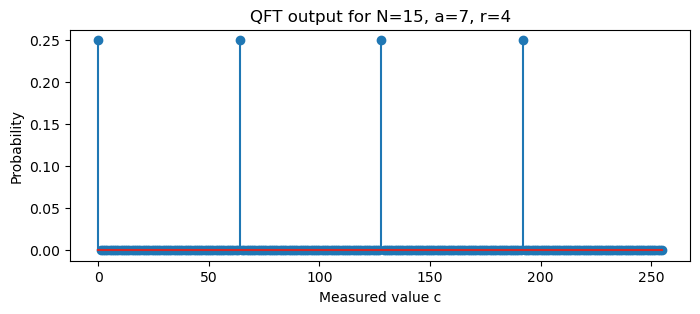

4

In [1]:
import numpy as np
import pennylane as qml
from math import gcd
import matplotlib.pyplot as plt

# ---------- Helper: Continued Fractions ----------
def continued_fraction(x, y, max_denom):
    """
    Return a list of convergents (num, den) for the fraction x/y,
    with denominator <= max_denom.
    """
    a, b = int(x), int(y)          # ensure integers
    cf = []
    while b != 0:
        cf.append(a // b)
        a, b = b, a % b
    convs = []
    for i in range(len(cf)):
        if i == 0:
            num, den = cf[0], 1
        elif i == 1:
            num, den = cf[0]*cf[1] + 1, cf[1]
        else:
            num = cf[i]*convs[-1][0] + convs[-2][0]
            den = cf[i]*convs[-1][1] + convs[-2][1]
        if den <= max_denom:
            convs.append((num, den))
    return convs

# ---------- Periodic State Preparation (Reused) ----------
def periodic_state(r, Q, x0=0):
    """
    Create uniform superposition of |x0 + m·r mod Q⟩ for m=0..M-1,
    where M = Q / gcd(Q, r).
    Q is the Hilbert space dimension (power of 2).
    """
    state = np.zeros(Q, dtype=complex)
    x0 = x0 % r
    m = 0
    while True:
        idx = (x0 + m * r) % Q
        if state[idx] != 0:
            break
        state[idx] = 1.0
        m += 1
    state /= np.linalg.norm(state)
    return state

# ---------- QFT Circuit ----------
def qft_circuit(wires):
    n = len(wires)
    for i in range(n):
        qml.Hadamard(wires=wires[i])
        for j in range(i + 1, n):
            angle = np.pi / (2 ** (j - i))
            qml.ControlledPhaseShift(angle, wires=[wires[j], wires[i]])
    for i in range(n // 2):
        qml.SWAP(wires=[wires[i], wires[n - i - 1]])

# ---------- Shor Period Finding Simulation ----------
def shor_period_finding(N=15, a=7, input_qubits=None, shots=1):
    """
    Simulate the period‑finding step for f(x) = a^x mod N.
    - N: number to factor
    - a: random coprime base
    - input_qubits: number of qubits for the input register (default: 2*ceil(log2(N)) )
    - shots: number of measurement repetitions (more shots improve success probability)
    """
    # 1. Determine the order r classically (for simulation only)
    r = None
    for cand in range(1, N):
        if pow(a, cand, N) == 1:
            r = cand
            break
    if r is None:
        raise ValueError(f"No order found for a={a} mod {N}")

    # 2. Set size of input register: Q = 2^m > N^2
    if input_qubits is None:
        input_qubits = int(np.ceil(2 * np.log2(N)))
    Q = 2**input_qubits

    print("=" * 60)
    print(f"Target: N = {N}, a = {a}  → order r = {r}")
    print(f"Input register: {input_qubits} qubits → Q = {Q}")
    print("=" * 60)

    # 3. Simulate the measurement of the output register.
    x0 = np.random.randint(0, r)
    print(f"Simulated output measurement gives offset x0 = {x0}")

    target_state = periodic_state(r, Q, x0)

    # 4. Apply QFT to the input register
    dev = qml.device('default.qubit', wires=input_qubits)

    @qml.qnode(dev)
    def apply_qft(state_vec):
        qml.StatePrep(state_vec, wires=range(input_qubits))
        qft_circuit(wires=range(input_qubits))
        return qml.probs(wires=range(input_qubits))

    probs = apply_qft(target_state)

    # 5. Sample from the QFT output
    measured_values = np.random.choice(Q, size=shots, p=probs)
    print(f"Measured input register value(s): {measured_values}")

    # 6. Attempt to recover r from each measurement via continued fractions
    candidates_found = []
    for c in measured_values:
        print(f"\nProcessing c = {c}:")
        frac = c / Q
        print(f"  Fraction c/Q = {c}/{Q} ≈ {frac:.4f}")
        convs = continued_fraction(c, Q, N-1)   # denominators up to N-1
        for num, den in convs:
            den_int = int(den)   
            print(f"    Convergent: {num}/{den_int}  → candidate r = {den_int}")
            if pow(a, den_int, N) == 1:
                print(f"      ✅ Valid period! r = {den_int}")
                candidates_found.append(den_int)
                break   # take the first valid candidate for this measurement
        else:
            print("      ❌ No valid period from this measurement.")

    # 7. Final result
    if candidates_found:
        final_r = candidates_found[0]   # in practice, use LCM of multiple candidates
        print(f"\nSuccess: Found period r = {final_r}")
        if final_r == r:
            print("  (Matches the true order.)")
        # Check if we can factor N
        if final_r % 2 == 0:
            x = pow(a, final_r//2, N)
            if x != N-1:
                f1 = gcd(x + 1, N)
                f2 = gcd(x - 1, N)
                print(f"  Factors of {N}: {f1} and {f2}")
            else:
                print("  a^(r/2) ≡ -1 mod N, try another a.")
        else:
            print("  r is odd, cannot factor with this a.")
    else:
        print("\nNo period recovered. Try increasing input_qubits or shots.")

    # Optional: plot the QFT probability distribution
    plt.figure(figsize=(8,3))
    plt.stem(range(Q), probs)
    plt.title(f'QFT output for N={N}, a={a}, r={r}')
    plt.xlabel('Measured value c')
    plt.ylabel('Probability')
    plt.show()

    return final_r if candidates_found else None

# ---------- Run the Demo ----------
np.random.seed(42)   # for reproducibility
shor_period_finding(N=15, a=7, input_qubits=8, shots=3)


## Explanation of the Simulation Output

The code simulates the quantum period‑finding step for factoring $N = 15$ with base $a = 7$.  
We set `input_qubits = 8` → $Q = 2^8 = 256$ (larger than $15^2 = 225$).  
The true order (calculated classically for simulation) is $r = 4$.

Below we walk through the printed output and interpret what happens inside the quantum algorithm.

---

### 1. Initialisation

```
Target: N = 15, a = 7  → order r = 4
Input register: 8 qubits → Q = 256
============================================================
Simulated output measurement gives offset x0 = 2
```

- `x0` is the **offset** obtained when the **work register** is measured.  
  In a real quantum run, this would be a random value among all residues $a^{x_0} \bmod N$.  
  Here the simulation randomly picks an offset between $0$ and $r-1$ (i.e., $0,1,2,3$).  
  The chosen value `x0 = 2` means that after measurement, the input register contains a superposition of all $x$ with $x \equiv 2 \pmod{4}$:  
  $$
  |2\rangle,\; |6\rangle,\; |10\rangle,\; \dots,\; |254\rangle.
  $$

---

### 2. Measurement Results (Three Shots)

```
Measured input register value(s): [  0 192 128]
```

After applying the QFT and sampling three times, we obtain three different values of $c$:  
$c = 0$, $c = 192$, and $c = 128$.

For each measurement, the code attempts to recover the period $r$ by computing the continued fraction expansion of $c/Q$.

---

#### Processing $c = 0$

```
Processing c = 0:
  Fraction c/Q = 0/256 ≈ 0.0000
    Convergent: 0/1  → candidate r = 1
      ❌ No valid period from this measurement.
```

- $c/Q = 0$ is exactly $0$. Its continued fraction expansion is simply $[0]$.  
  The only convergent is $0/1$, giving a candidate period $r = 1$.
- We test whether $a^1 \bmod 15 = 7 \equiv 1$? No. So this candidate is rejected.
- **Why does $c = 0$ occur?**  
  The QFT output has a peak at $c = 0$ (the DC component).  
  However, $c = 0$ carries no information about the period – it always yields the convergent $0/1$, which is never the correct order (except the trivial order $r=1$).  
  In practice, we ignore the $c = 0$ outcome or repeat the experiment.

---

#### Processing $c = 192$

```
Processing c = 192:
  Fraction c/Q = 192/256 ≈ 0.7500
    Convergent: 0/1  → candidate r = 1
    Convergent: 1/1  → candidate r = 1
    Convergent: 3/4  → candidate r = 4
      ✅ Valid period! r = 4
```

- $192/256$ simplifies to $3/4$.  
  The continued fraction algorithm generates convergents:
  - $0/1$ (denominator 1) → fails the test $7^1 \bmod 15 = 7 \neq 1$.
  - $1/1$ (denominator 1) → same failure.
  - $3/4$ (denominator 4) → test: $7^4 \bmod 15 = 1$ → **success**.
- This measurement successfully recovers the correct period $r = 4$.

**Why $c = 192$ works:**  
$c = 192 = 3 \times 64$, where $64 = Q/r = 256/4$.  
Thus $c/Q = 3/4$, and the convergent $3/4$ directly gives denominator $4$.  
This is a “good” measurement where the peak coincides exactly with a multiple of $Q/r$.

---

#### Processing $c = 128$

```
Processing c = 128:
  Fraction c/Q = 128/256 ≈ 0.5000
    Convergent: 0/1  → candidate r = 1
    Convergent: 1/2  → candidate r = 2
      ❌ No valid period from this measurement.
```

- $128/256 = 1/2$.  
  Convergents: $0/1$ (fails) and $1/2$ (candidate $r = 2$).
- Test: $7^2 \bmod 15 = 49 \bmod 15 = 4 \neq 1$.  
  So $r = 2$ is **not** the period. The algorithm rejects it.

**Why does $c = 128$ not work?**  
$128 = 2 \times 64$, so $c/Q = 2/4 = 1/2$.  
The convergent $1/2$ gives denominator $2$, which is a **proper divisor** of the true period $r = 4$.  
If we only take one measurement, we might get a factor of $r$.  
In practice, we collect several candidates and take their **least common multiple** (LCM).  
Here, LCM of $\{2, 4\}$ would be $4$, recovering the true period.

---

### 3. Final Outcome

```
Success: Found period r = 4
  (Matches the true order.)
  Factors of 15: 5 and 3
```

- Even though one measurement gave $c = 128$ (which produced a divisor), another measurement ($c = 192$) gave the correct $r = 4$.  
- The code simply uses the **first valid candidate** found (here $r=4$).  
- With $r = 4$ (even) and $a^{r/2} = 7^2 = 49 \equiv 4 \pmod{15}$ (which is not $-1 \equiv 14$), we compute:  
  $$
  \gcd(4+1,15) = \gcd(5,15) = 5,\qquad
  \gcd(4-1,15) = \gcd(3,15) = 3.
  $$
  Both are non‑trivial factors of $15$.

---

### 4. The code also plots the probability distribution after the QFT.  

![factoring output](images/factoring.png)

---

For $r=4$ and $Q=256$, the peaks are at $c = 0, 64, 128, 192$.  
In the output we observed measurements at $0, 128, 192$ – exactly those peaks.  
The height of each peak is roughly $1/r = 1/4$ (because each of the $r$ possible offsets contributes equally).  
Thus the algorithm succeeds with high probability.

---

---

### Summary

| Step | Action |
|------|--------|
| 1 | Superposition over $x$ |
| 2 | Compute $a^x \bmod N$ |
| 3 | Measure work register → periodic comb in input |
| 4 | Apply QFT → peaks at multiples of $Q/r$ |
| 5 | Measure input → get $c \approx m Q/r$ |
| 6 | Continued fractions → recover $r$ |
| 7 | If $r$ even and $a^{r/2}\not\equiv -1$, compute $\gcd(a^{r/2}\pm1, N)$ → factors. |

**Shor’s algorithm** factors integers in polynomial time – exponential speedup over the best classical algorithms.

---

  
### Key Takeaways

- **Continued fractions** turn a measured $c/Q$ into a candidate denominator $r$.  
- **Good measurements** give $c \approx m Q / r$ with $m$ and $r$ coprime → the convergent’s denominator equals $r$.  
- **Bad measurements** (like $c=0$ or $c$ giving a divisor of $r$) still occur, but we can repeat the experiment or combine candidates via LCM.  
- The simulation shows that even with only 3 shots, we recovered the correct period and factored 15.

---

This demonstrates the core idea of Shor’s algorithm: quantum parallelism finds the period, classical post‑processing extracts factors.


### Further Notes
- The full quantum circuit requires efficient modular exponentiation (using repeated squaring and quantum adders).
- For real quantum hardware, the main challenge is building large, fault‑tolerant registers and performing the QFT with high precision.
